# Import

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2025-11-16 08:39:41.618030: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763282381.826831      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763282381.876793      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [ ]:
TRAIN_DIR  = '/kaggle/input/cs406-intel-classification-data/dataset/seg'
TEST_DIR  = '/kaggle/input/cs406-intel-classification-data/dataset/seg_test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25
NUM_CLASSES = 6
SEED = 42

In [4]:
def build_model(base_model):
    base_model.trainable = False   # Freeze backbone

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    output = Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [5]:
def train_model(model, name, preprocess_func):
    train_gen = ImageDataGenerator(
        preprocessing_function=preprocess_func,
        validation_split=0.2,
        rotation_range=20,
        zoom_range=0.15,
        shear_range=0.1,
        horizontal_flip=True
    )
    
    val_gen = ImageDataGenerator(
        preprocessing_function=preprocess_func,
        validation_split=0.2
    )
    
    train_data = train_gen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        subset="training",
        seed=SEED
    )
    
    val_data = val_gen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        subset="validation",
        seed=SEED
    )
    
    test_gen = ImageDataGenerator(preprocessing_function=preprocess_func)
    
    test_data = test_gen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    print(f"\n==================== TRAINING {name} ====================\n")

    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3),
        ModelCheckpoint(f"{name}.h5", monitor="val_accuracy", save_best_only=True)
    ]

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        callbacks=callbacks
    )

    print(f"\n>>> Model saved: {name}.h5\n")
    return test_data, history

In [6]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14,5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


In [7]:
def evaluate_model(model, test_data, model_name):
    # Predict
    preds = model.predict(test_data)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_data.classes
    labels = list(test_data.class_indices.keys())

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"\n============================")
    print(f" Evaluation: {model_name}")
    print(f" Accuracy: {acc:.4f}")
    print(f"============================\n")

    # Classification Report
    print(classification_report(y_true, y_pred, target_names=labels))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png")
    plt.show()

    print(f"Confusion matrix saved to {model_name}_confusion_matrix.png\n")

# Model VGG16

In [8]:
vgg = VGG16(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
model_vgg = build_model(vgg)
test_data, history_vgg = train_model(model_vgg, "VGG16_Intel", vgg_preprocess)

I0000 00:00:1763282398.783613      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763282398.784331      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

==================== TRAINING VGG16_Intel ====================



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1763282411.108793      62 service.cc:148] XLA service 0x7fbae0005280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763282411.109514      62 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763282411.109535      62 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763282411.508322      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


...

351/351 ━━━━━━━━━━━━━━━━━━━━ 141s 402ms/step - accuracy: 0.8884 - loss: 0.3117 - val_accuracy: 0.9105 - val_loss: 0.2728 - learning_rate: 0.0010
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.8978 - loss: 0.2795

351/351 ━━━━━━━━━━━━━━━━━━━━ 140s 398ms/step - accuracy: 0.8979 - loss: 0.2795 - val_accuracy: 0.9158 - val_loss: 0.2697 - learning_rate: 0.0010
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 141s 402ms/step - accuracy: 0.9093 - loss: 0.2520 - val_accuracy: 0.9133 - val_loss: 0.2658 - learning_rate: 0.0010
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 139s 396ms/step - accuracy: 0.9115 - loss: 0.2341 - val_accuracy: 0.9158 - val_loss: 0.2596 - learning_rate: 0.0010
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 139s 396ms/step - accuracy: 0.9180 - loss: 0.2190 - val_accuracy: 0.9073 - val_loss: 0.3027 - learning_rate: 0.0010
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9164 - loss: 0.2247

351/351 ━━━━━━━━━━━━━━━━━━━━ 140s 398ms/step - accuracy: 0.9164 - loss: 0.2247 - val_accuracy: 0.9194 - val_loss: 0.2662 - learning_rate: 0.0010
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 139s 395ms/step - accuracy: 0.9192 - loss: 0.2185 - val_accuracy: 0.9165 - val_loss: 0.2665 - learning_rate: 0.0010
Epoch 9/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9353 - loss: 0.1834

351/351 ━━━━━━━━━━━━━━━━━━━━ 141s 401ms/step - accuracy: 0.9353 - loss: 0.1834 - val_accuracy: 0.9240 - val_loss: 0.2487 - learning_rate: 3.0000e-04
Epoch 10/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9370 - loss: 0.1749

351/351 ━━━━━━━━━━━━━━━━━━━━ 139s 397ms/step - accuracy: 0.9370 - loss: 0.1749 - val_accuracy: 0.9265 - val_loss: 0.2463 - learning_rate: 3.0000e-04
Epoch 11/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 145s 413ms/step - accuracy: 0.9353 - loss: 0.1739 - val_accuracy: 0.9248 - val_loss: 0.2582 - learning_rate: 3.0000e-04
Epoch 12/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 140s 398ms/step - accuracy: 0.9374 - loss: 0.1725 - val_accuracy: 0.9251 - val_loss: 0.2448 - learning_rate: 3.0000e-04
Epoch 13/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 140s 397ms/step - accuracy: 0.9377 - loss: 0.1599 - val_accuracy: 0.9230 - val_loss: 0.2592 - learning_rate: 3.0000e-04
Epoch 14/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 403ms/step - accuracy: 0.9411 - loss: 0.1496 - val_accuracy: 0.9201 - val_loss: 0.2662 - learning_rate: 3.0000e-04
Epoch 15/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 404ms/step - accuracy: 0.9413 - loss: 0.1574 - val_accuracy: 0.9251 - val_loss: 0.2568 - learning_rate: 3.0000e-04

>>> Model saved: VGG16_Intel.h5



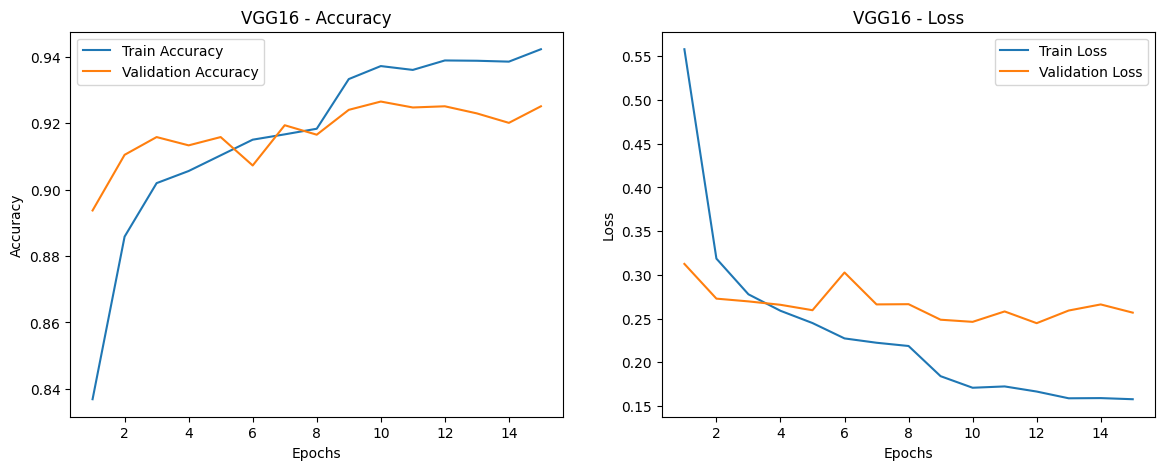

In [9]:
plot_history(history_vgg, "VGG16")

94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 289ms/step

 Evaluation: VGG16
 Accuracy: 0.9200

              precision    recall  f1-score   support

   buildings       0.93      0.92      0.93       437
      forest       0.99      0.99      0.99       474
     glacier       0.86      0.86      0.86       553
    mountain       0.89      0.85      0.87       525
         sea       0.94      0.97      0.95       510
      street       0.93      0.94      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



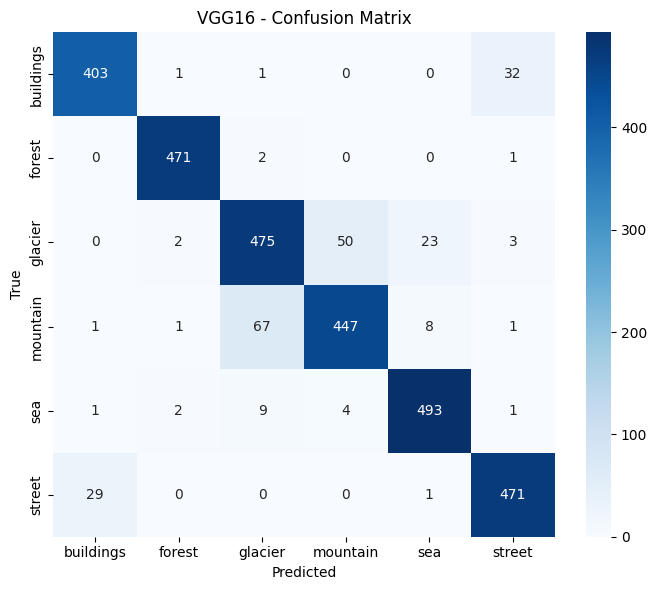

Confusion matrix saved to VGG16_confusion_matrix.png



In [10]:
evaluate_model(model_vgg, test_data, "VGG16")

# Model EfficientNetB0

In [11]:
effnet = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
model_effnet = build_model(effnet)
test_data, history_effnet = train_model(model_effnet, "EfficientNetB0_Intel", eff_preprocess)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

==================== TRAINING EfficientNetB0_Intel ====================



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.8467 - loss: 0.4289

351/351 ━━━━━━━━━━━━━━━━━━━━ 160s 400ms/step - accuracy: 0.8468 - loss: 0.4285 - val_accuracy: 0.9226 - val_loss: 0.2099 - learning_rate: 0.0010
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 131s 372ms/step - accuracy: 0.9147 - loss: 0.2322 - val_accuracy: 0.9201 - val_loss: 0.2123 - learning_rate: 0.0010
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9248 - loss: 0.2025

351/351 ━━━━━━━━━━━━━━━━━━━━ 128s 366ms/step - accuracy: 0.9248 - loss: 0.2025 - val_accuracy: 0.9290 - val_loss: 0.1938 - learning_rate: 0.0010
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 121s 345ms/step - accuracy: 0.9276 - loss: 0.1936 - val_accuracy: 0.9240 - val_loss: 0.2078 - learning_rate: 0.0010
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 121s 344ms/step - accuracy: 0.9320 - loss: 0.1819 - val_accuracy: 0.9269 - val_loss: 0.1960 - learning_rate: 0.0010
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 121s 345ms/step - accuracy: 0.9392 - loss: 0.1722 - val_accuracy: 0.9198 - val_loss: 0.2240 - learning_rate: 0.0010
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9456 - loss: 0.1526

351/351 ━━━━━━━━━━━━━━━━━━━━ 122s 348ms/step - accuracy: 0.9456 - loss: 0.1526 - val_accuracy: 0.9297 - val_loss: 0.1981 - learning_rate: 3.0000e-04
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.9458 - loss: 0.1431

351/351 ━━━━━━━━━━━━━━━━━━━━ 121s 345ms/step - accuracy: 0.9458 - loss: 0.1430 - val_accuracy: 0.9305 - val_loss: 0.1999 - learning_rate: 3.0000e-04
Epoch 9/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9528 - loss: 0.1323

351/351 ━━━━━━━━━━━━━━━━━━━━ 122s 348ms/step - accuracy: 0.9528 - loss: 0.1323 - val_accuracy: 0.9315 - val_loss: 0.1938 - learning_rate: 3.0000e-04
Epoch 10/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 127s 362ms/step - accuracy: 0.9534 - loss: 0.1191 - val_accuracy: 0.9294 - val_loss: 0.1947 - learning_rate: 9.0000e-05
Epoch 11/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 127s 362ms/step - accuracy: 0.9513 - loss: 0.1274 - val_accuracy: 0.9290 - val_loss: 0.1968 - learning_rate: 9.0000e-05
Epoch 12/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 124s 354ms/step - accuracy: 0.9518 - loss: 0.1207 - val_accuracy: 0.9297 - val_loss: 0.1941 - learning_rate: 9.0000e-05
Epoch 13/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 126s 359ms/step - accuracy: 0.9545 - loss: 0.1210 - val_accuracy: 0.9301 - val_loss: 0.1940 - learning_rate: 2.7000e-05
Epoch 14/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 128s 365ms/step - accuracy: 0.9538 - loss: 0.1195 - val_accuracy: 0.9315 - val_loss: 0.1946 - learning_rate: 2.7000e-05

>>> Model saved: EfficientNetB0_Intel.h5



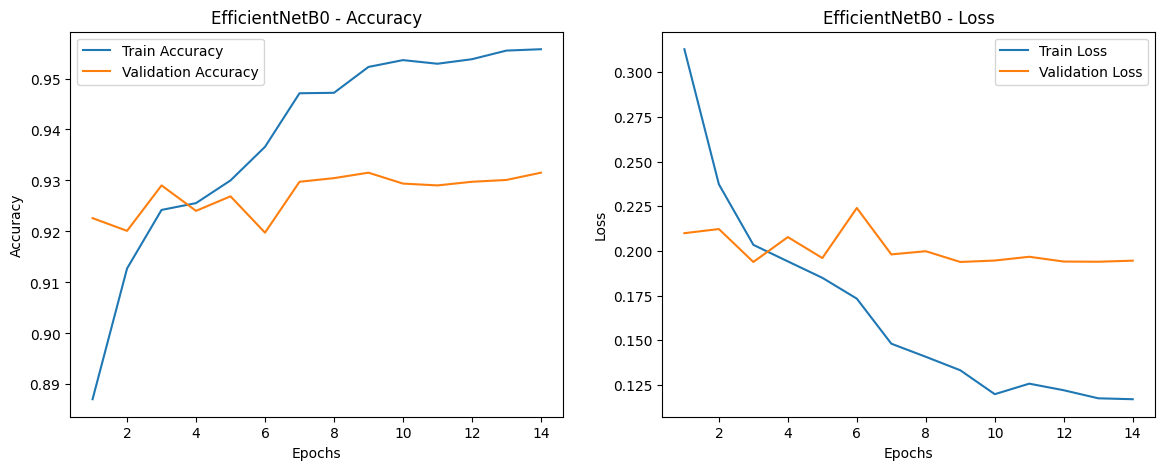

In [12]:
plot_history(history_effnet, "EfficientNetB0")

94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step

 Evaluation: EfficientNetB0
 Accuracy: 0.9280

              precision    recall  f1-score   support

   buildings       0.93      0.93      0.93       437
      forest       1.00      0.99      0.99       474
     glacier       0.88      0.87      0.88       553
    mountain       0.89      0.88      0.89       525
         sea       0.95      0.97      0.96       510
      street       0.93      0.94      0.94       501

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



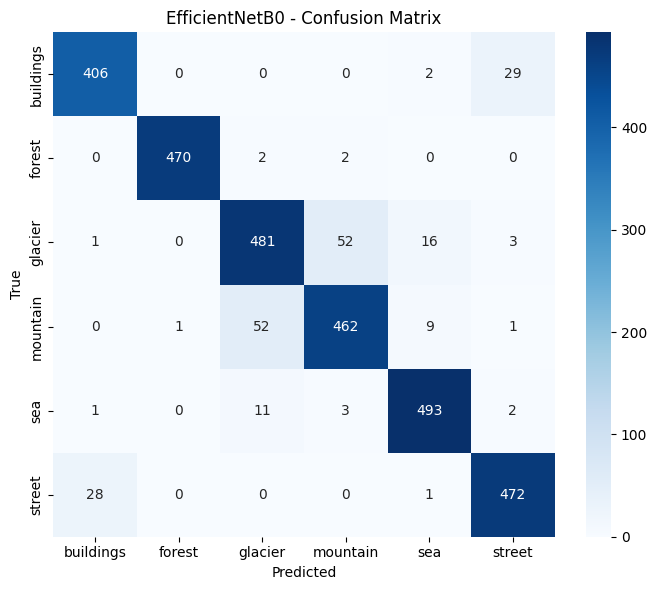

Confusion matrix saved to EfficientNetB0_confusion_matrix.png



In [13]:
evaluate_model(model_effnet, test_data, "EfficientNetB0")

# Model ResNet50

In [14]:
resnet = ResNet50(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
model_resnet = build_model(resnet)
test_data, history_resnet = train_model(model_resnet, "ResNet50_Intel", resnet_preprocess)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

==================== TRAINING ResNet50_Intel ====================



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.8312 - loss: 0.4902

351/351 ━━━━━━━━━━━━━━━━━━━━ 153s 400ms/step - accuracy: 0.8313 - loss: 0.4898 - val_accuracy: 0.9183 - val_loss: 0.2235 - learning_rate: 0.0010
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9069 - loss: 0.2553

351/351 ━━━━━━━━━━━━━━━━━━━━ 128s 363ms/step - accuracy: 0.9069 - loss: 0.2553 - val_accuracy: 0.9226 - val_loss: 0.2109 - learning_rate: 0.0010
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.9139 - loss: 0.2334

351/351 ━━━━━━━━━━━━━━━━━━━━ 129s 366ms/step - accuracy: 0.9139 - loss: 0.2334 - val_accuracy: 0.9294 - val_loss: 0.2199 - learning_rate: 0.0010
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 128s 364ms/step - accuracy: 0.9257 - loss: 0.2043 - val_accuracy: 0.9233 - val_loss: 0.2131 - learning_rate: 0.0010
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 127s 360ms/step - accuracy: 0.9253 - loss: 0.1984 - val_accuracy: 0.9255 - val_loss: 0.2062 - learning_rate: 0.0010
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 128s 363ms/step - accuracy: 0.9277 - loss: 0.1924 - val_accuracy: 0.9194 - val_loss: 0.2248 - learning_rate: 0.0010
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 131s 372ms/step - accuracy: 0.9301 - loss: 0.1845 - val_accuracy: 0.9198 - val_loss: 0.2544 - learning_rate: 0.0010
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 127s 363ms/step - accuracy: 0.9341 - loss: 0.1801 - val_accuracy: 0.9287 - val_loss: 0.2252 - learning_rate: 0.0010

>>> Model saved: ResNet50_Intel.h5



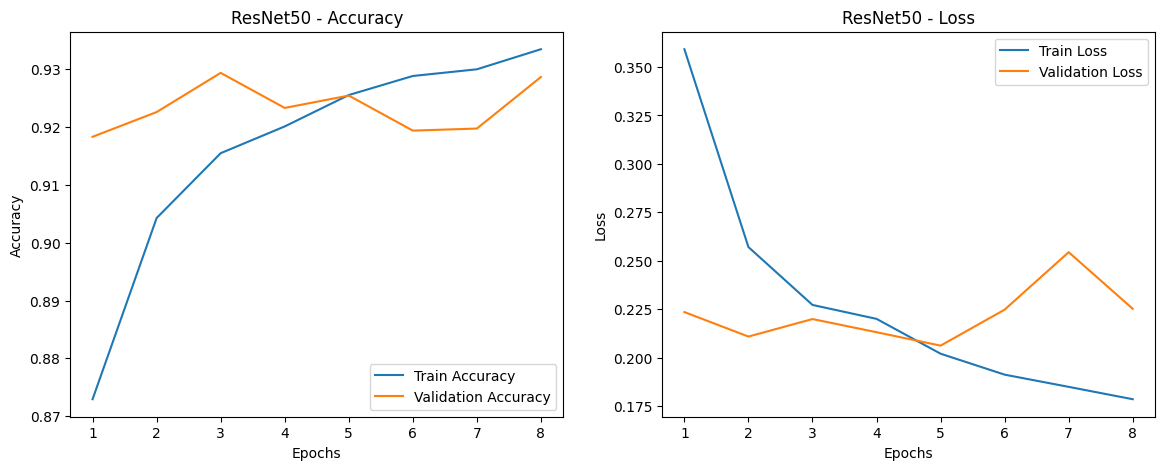

In [15]:
plot_history(history_resnet, "ResNet50")

94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 152ms/step

 Evaluation: ResNet50
 Accuracy: 0.9200

              precision    recall  f1-score   support

   buildings       0.95      0.89      0.92       437
      forest       0.98      1.00      0.99       474
     glacier       0.89      0.85      0.87       553
    mountain       0.88      0.86      0.87       525
         sea       0.92      0.99      0.95       510
      street       0.92      0.94      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



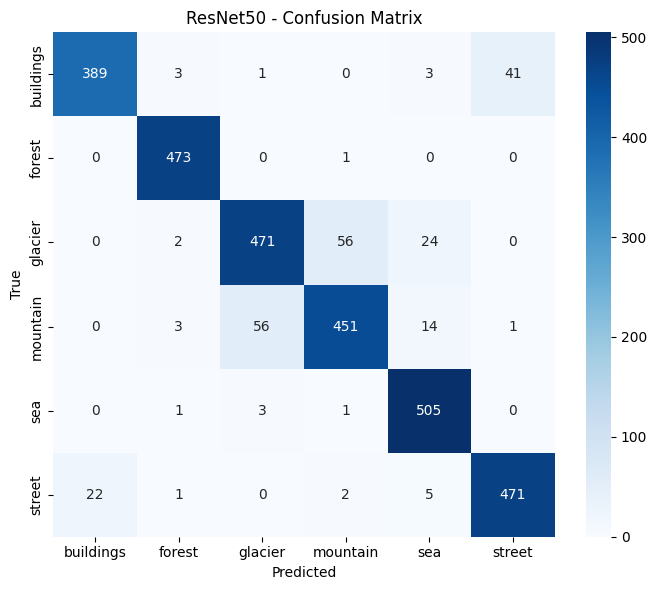

Confusion matrix saved to ResNet50_confusion_matrix.png



In [16]:
evaluate_model(model_resnet, test_data, "ResNet50")